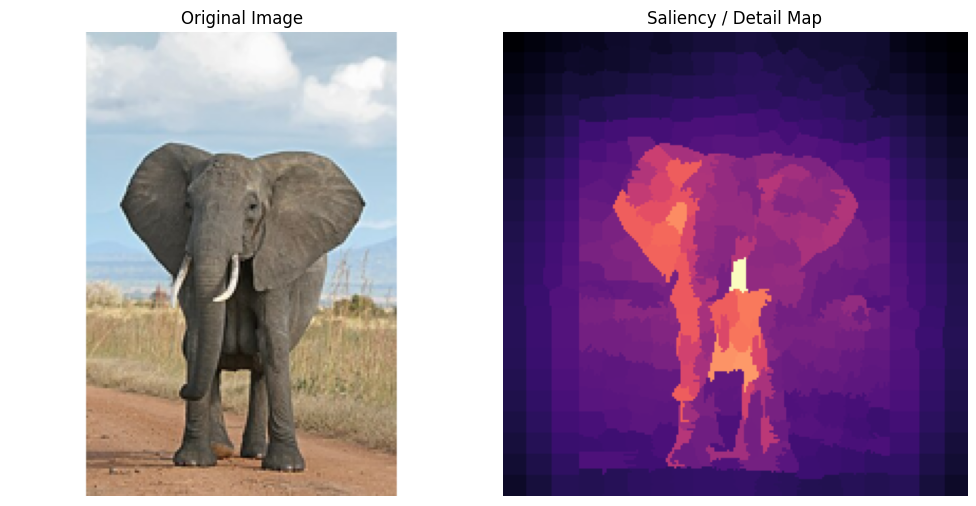

In [1]:
import numpy as np
from PIL import Image, ImageOps
from skimage.segmentation import slic
from skimage.color import rgb2lab
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# --- Configuration ---
IMAGE_SIZE = 220

# 1. Load your PIL image
pil_image = Image.open("C:/Users/Simon/Documents/projecten/paint-bot/images/elephant.jpg")

# 2. Rescale to 220x220
resized_image = ImageOps.pad(pil_image, (IMAGE_SIZE, IMAGE_SIZE), color=(255, 255, 255))

# 3. Convert to NumPy array
image = np.array(resized_image)

# 4. Run SLIC segmentation
segments = slic(
    image,
    n_segments=500,
    compactness=10,
    start_label=0
)

# 5. Calculate Saliency Map
# Convert to LAB color space (better matches human perception of color differences)
lab_image = rgb2lab(image)
num_segments = np.max(segments) + 1

# Find the mean LAB color and center position (Y, X) for each superpixel
features = []
positions = []

for i in range(num_segments):
    mask = (segments == i)
    if not np.any(mask):
        features.append([0, 0, 0])
        positions.append([0, 0])
        continue
        
    # Mean color
    mean_color = lab_image[mask].mean(axis=0)
    features.append(mean_color)
    
    # Mean position (spatial location)
    y, x = np.argwhere(mask).mean(axis=0)
    positions.append([y, x])

features = np.array(features)
positions = np.array(positions)

# Calculate color distances between all pairs of superpixels
color_distances = cdist(features, features, metric='euclidean')

# Calculate spatial distances (to penalize elements that are far apart)
# Humans tend to look at unique elements, but if a color is repeated *everywhere*, it's a background.
spatial_distances = cdist(positions, positions, metric='euclidean')
spatial_weights = np.exp(-spatial_distances / (IMAGE_SIZE * 0.3)) # Adjust 0.3 to change locality bias

# Saliency of a superpixel = sum of color differences to all other superpixels, 
# weighted by how close they are spatially.
weighted_distances = color_distances * spatial_weights
saliency_per_segment = weighted_distances.sum(axis=1)

# Normalize saliency to [0, 1]
saliency_per_segment = (saliency_per_segment - saliency_per_segment.min()) / (saliency_per_segment.max() - saliency_per_segment.min() + 1e-8)

# Map the superpixel saliency back to the full image dimensions
saliency_map = saliency_per_segment[segments]

# --- 6. Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Display heatmap overlay
# axes[1].imshow(image)
axes[1].imshow(saliency_map, cmap='magma') # 'jet' gives the classic red/blue heatmap
axes[1].set_title("Saliency / Detail Map")
axes[1].axis("off")

plt.tight_layout()
plt.show()